# Assignment 3

In [2]:
#Adding libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate, stats
from astroML.density_estimation import EmpiricalDistribution

Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey (SDSS).

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data of 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST (and EUCLID), while we already are collecting data w DESI and DES). The latest public data release as of 2025 is SDSS Data Release 19 (DR19) with over a billion photometric objects and over 3 million spectroscopically confirmed galaxies or quasars.  

![](https://classic.sdss.org/includes/sideimages/sdss_pie2.jpg)

Download the SDSS quasar data. There is an older version (see Davide's implementation). Here I will use the latest one, DR16. However, this is a very large file. Do not try to download unless you are on your own machine. Instead, you can find the extracted redshifts in a Data folder on GitHub (see below how to access). There are many other interesting data points in the fits file that we could play with.  

Now you can just import the file as:

    import numpy as np
    z_clean = np.load("../Data/quasar_redshifts.npz")["z"]


In [3]:
z_clean = np.load("../Data/quasar_redshifts.npz")["z"]

Now comes the assignment:

- Upsample this distribution in two ways, using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distributions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures).

(Hint: `scipy.stats` is your best friend)

- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theoretical distribution to the measured SDSS data

(Hint: `astropy.cosmology` is another close friend).

Maximum value in z_clean: 7.023917198181152 
Minimum value in z_clean: 0.0006907593342475593


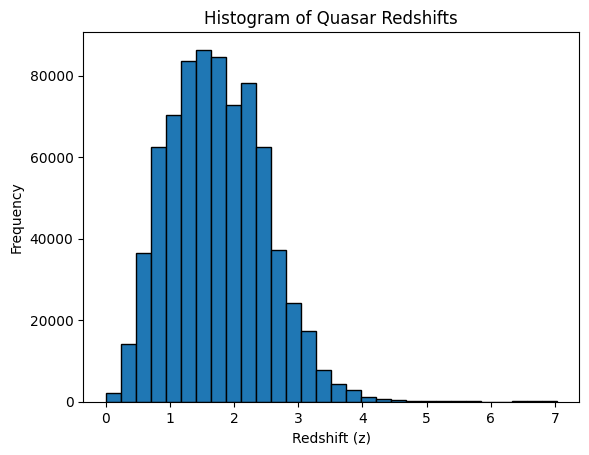

In [4]:
plt.hist(z_clean, bins=30, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Frequency')
plt.title('Histogram of Quasar Redshifts')
print("Maximum value in z_clean:", np.max(z_clean), "\nMinimum value in z_clean:", np.min(z_clean))

## Rejection Sampling

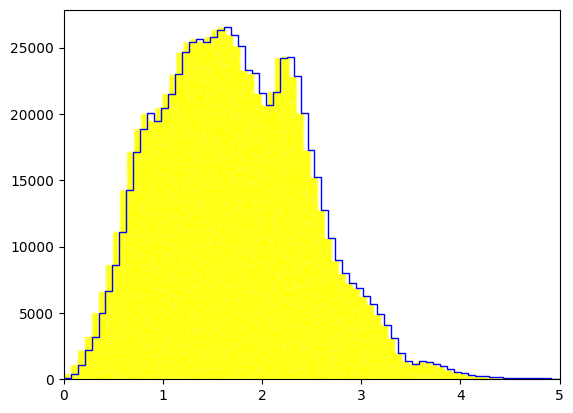

1948457 750404


In [27]:
x_max = np.max(z_clean)
N = len(z_clean)*10
distribution = np.histogram(z_clean, bins=100)[0]
xg = np.linspace(0, x_max, 100)
np.random.seed(0)  # For reproducibility
x = np.random.uniform(0, x_max, N)
y = np.random.uniform(0, np.max(distribution)*1.1, N)  
mask = y < distribution[np.searchsorted(xg, x)]

plt.hist(z_clean, bins = 100, label='Data', edgecolor='blue', histtype='step')

plt.scatter(x[mask], y[mask], c='yellow', s = 0.0001) # plot points below the curve in yellow 
plt.xlim(0, 5)

plt.show()
good_points = x[mask]
print(len(good_points), len(z_clean))

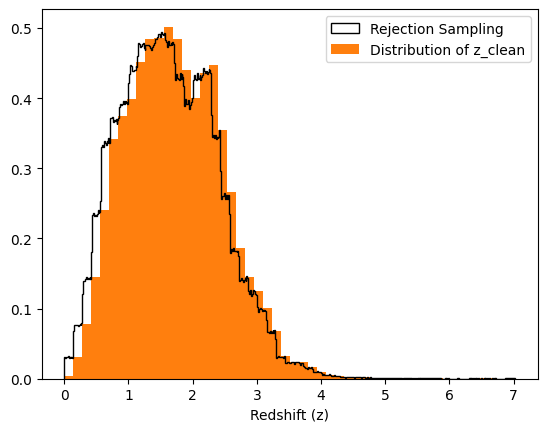

In [6]:
good_points = x[mask]
distribution = np.histogram(z_clean, bins=50, range=(0, x_max), density=True)[0]
xg = np.linspace(0, x_max, 50)
plt.hist(good_points, bins=500, edgecolor='black', histtype='step', label='Rejection Sampling', density=True)
plt.hist(z_clean, bins=50, label='Distribution of z_clean', density=True)
plt.xlabel('Redshift (z)')
plt.legend()
plt.show()

Pretty similar, but a little shifted to the right

# 

## Inverse Transform

C:\Users\Renzovm\AppData\Local\Temp\ipykernel_13976\227097573.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


3752 750404


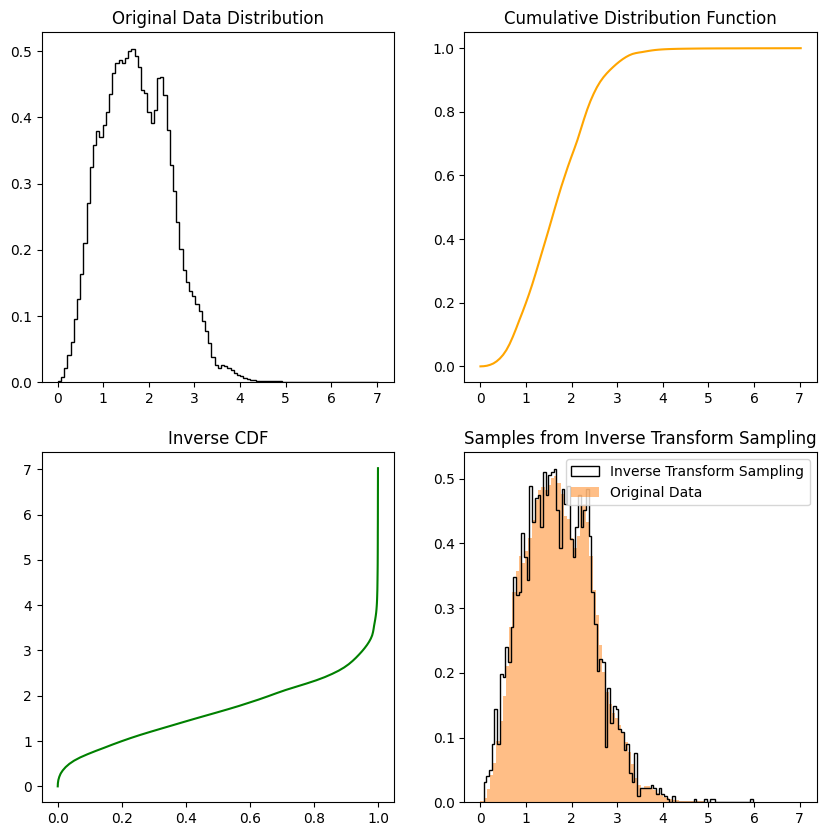

In [21]:
n_bins = 100

x_max = np.max(z_clean)
xg = np.linspace(0, x_max, n_bins)

np.random.seed(120)  # For reproducibility

N_data = len(z_clean)
N_samples = N_data // 200
distr = np.histogram(z_clean, bins=n_bins, density=True)[0]
distr_cum = np.cumsum(distr) / np.sum(distr)

u = np.random.uniform(0, 1, N_samples)
x_sample = np.interp(u, distr_cum, xg)


fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].hist(z_clean, bins=n_bins, edgecolor='black', histtype='step', label='Data', density=True)
ax[0, 0].set_title('Original Data Distribution')

ax[0, 1].plot(xg, distr_cum, label='Cumulative Distribution', color='orange')
ax[0, 1].set_title('Cumulative Distribution Function')

ax[1, 0].plot(distr_cum, xg, label='Inverse CDF', color='green')
ax[1, 0].set_title('Inverse CDF')

ax[1, 1].hist(x_sample, bins=n_bins, edgecolor='black', histtype='step', label='Inverse Transform Sampling', density=True)
ax[1, 1].set_title('Samples from Inverse Transform Sampling')
ax[1, 1].hist(z_clean, bins=n_bins, label='Original Data', density=True, alpha=0.5)
ax[1, 1].legend()
fig.show()

print(len(x_sample), len(z_clean))

In [8]:
print(np.std(x_sample), np.std(z_clean))

0.7570589232446222 0.7489308909663035
